# CAPM Analysis

Merge csv files to one whole csv file more easy to handle with.

In [40]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import statsmodels.api as sm
from scipy import stats

from pathlib import Path

Create the normal daily return data

In [41]:
# Load daily returns
returns = pd.read_csv("../data/processed/daily_returns.csv")

# Load risk-free rate
rf = pd.read_csv("../data/risk_free/fred_dtb3.csv")

# Convert date columns
returns["date"] = pd.to_datetime(returns["date"])
rf["date"] = pd.to_datetime(rf["date"])

# turn annual risk free rate into daily decimal risk free rate
rf["Risk_Free_Rate"] = (
    (1 + rf["DTB3"] / 100) ** (1 / 252) - 1
)

# merge two dataframes on date column
df = pd.merge(
    returns,
    rf[["date", "Risk_Free_Rate"]],
    on="date",
    how="left"
)

# 按时间排序
df = df.sort_values("date").reset_index(drop=True)

# 缺失日沿用最近一次已知的无风险利率
df["Risk_Free_Rate"] = df["Risk_Free_Rate"].ffill()

$$
\text{excess stock return} = R_i - R_f
$$

$$
\text{excess market return} = R_m - R_f
$$

$$
R_i - R_f = \alpha + \beta(R_m - R_f) + \epsilon
$$

In [42]:
df["Market_Excess_Return"] = (df["SPY"] - df["Risk_Free_Rate"])

market_col = "SPY"

stock_cols = [
    col for col in returns.columns
    if col not in ["date", market_col]
]

for stock in stock_cols:
    df[f"{stock}_Excess_Return"] = (
        df[stock] - df["Risk_Free_Rate"]
    )

df.head()

,date,MSFT,GOOGL,AMZN,JPM,JNJ,PG,XOM,CAT,NEE,...,MSFT_Excess_Return,GOOGL_Excess_Return,AMZN_Excess_Return,JPM_Excess_Return,JNJ_Excess_Return,PG_Excess_Return,XOM_Excess_Return,CAT_Excess_Return,NEE_Excess_Return,APD_Excess_Return
0,2015-01-02,0.006674,-0.002092,-0.005897,0.004954,-0.000478,-0.007136,0.004110,0.003824,0.003763,...,0.006673,-0.002093,-0.005897,0.004953,-0.000479,-0.007137,0.004110,0.003823,0.003762,0.008319
1,2015-01-05,-0.009303,-0.019054,-0.020517,-0.031045,-0.006984,-0.004755,-0.027362,-0.052786,-0.010591,...,-0.009304,-0.019055,-0.020518,-0.031046,-0.006985,-0.004756,-0.027363,-0.052787,-0.010593,-0.031975
2,2015-01-06,-0.014571,-0.024679,-0.022833,-0.025929,-0.004914,-0.004555,-0.005316,-0.006435,0.003884,...,-0.014572,-0.024681,-0.022835,-0.025930,-0.004915,-0.004556,-0.005317,-0.006436,0.003883,-0.000356
3,2015-01-07,0.012705,-0.002941,0.010600,0.001526,0.022076,0.005246,0.010133,0.015497,0.009154,...,0.012704,-0.002942,0.010599,0.001525,0.022075,0.005244,0.010131,0.015496,0.009152,0.010800
4,2015-01-08,0.029418,0.003484,0.006836,0.022346,0.007863,0.011436,0.016645,0.010249,0.006078,...,0.029417,0.003483,0.006835,0.022345,0.007862,0.011434,0.016643,0.010248,0.006077,0.023127


In [43]:
stock_excess_cols = [
    col for col in df.columns
    if "Excess_Return" in col
    and col != "Market_Excess_Return"
]

stock_excess_return = df[stock_excess_cols]
stock_excess_return.head()

,MSFT_Excess_Return,GOOGL_Excess_Return,AMZN_Excess_Return,JPM_Excess_Return,JNJ_Excess_Return,PG_Excess_Return,XOM_Excess_Return,CAT_Excess_Return,NEE_Excess_Return,APD_Excess_Return
0,0.006673,-0.002093,-0.005897,0.004953,-0.000479,-0.007137,0.004110,0.003823,0.003762,0.008319
1,-0.009304,-0.019055,-0.020518,-0.031046,-0.006985,-0.004756,-0.027363,-0.052787,-0.010593,-0.031975
2,-0.014572,-0.024681,-0.022835,-0.025930,-0.004915,-0.004556,-0.005317,-0.006436,0.003883,-0.000356
3,0.012704,-0.002942,0.010599,0.001525,0.022075,0.005244,0.010131,0.015496,0.009152,0.010800
4,0.029417,0.003483,0.006835,0.022345,0.007862,0.011434,0.016643,0.010248,0.006077,0.023127


Table of each stock’s alpha, beta, R-squared, p-values

In [44]:
Market_excess_return = df["Market_Excess_Return"]
x = Market_excess_return 
results = []

for stock in stock_excess_cols:

    temp = df[["Market_Excess_Return", stock]].dropna()

    x = temp["Market_Excess_Return"]
    y = temp[stock]

    X = sm.add_constant(x)  # add constant term for intercept

    model = sm.OLS(y, X).fit(cov_type="HC3")

    # transfer to DataFrame and add to results list
    results.append({
        "Stock": stock,
        "Alpha": model.params["const"],
        "Beta": model.params["Market_Excess_Return"],
        "R_squared": model.rsquared,
        "Alpha_pvalue": model.pvalues["const"],
        "Beta_pvalue": model.pvalues["Market_Excess_Return"]
    })

results_df = pd.DataFrame(results)

results_df["Stock"] = (
    results_df["Stock"]
    .str.replace("_Excess_Return", "", regex=False)
)

print(results_df)

   Stock     Alpha      Beta  R_squared  Alpha_pvalue    Beta_pvalue
0   MSFT  0.000393  1.187671   0.617735      0.048697   0.000000e+00
1  GOOGL  0.000424  1.147625   0.501325      0.082651   0.000000e+00
2   AMZN  0.000537  1.183813   0.409175      0.079112  4.785782e-114
3    JPM  0.000234  1.099207   0.519174      0.297922  2.732633e-181
4    JNJ  0.000107  0.491280   0.230687      0.578091   2.814489e-59
5     PG  0.000017  0.511219   0.241408      0.929628   2.118186e-47
6    XOM -0.000065  0.828602   0.289202      0.813749   1.888337e-90
7    CAT  0.000340  1.081016   0.412020      0.220002  1.400590e-190
8    NEE  0.000235  0.640170   0.213160      0.371537   2.383775e-44
9    APD -0.000097  0.900577   0.394200      0.684675  1.076252e-210


Bar chart comparing betas across stocks

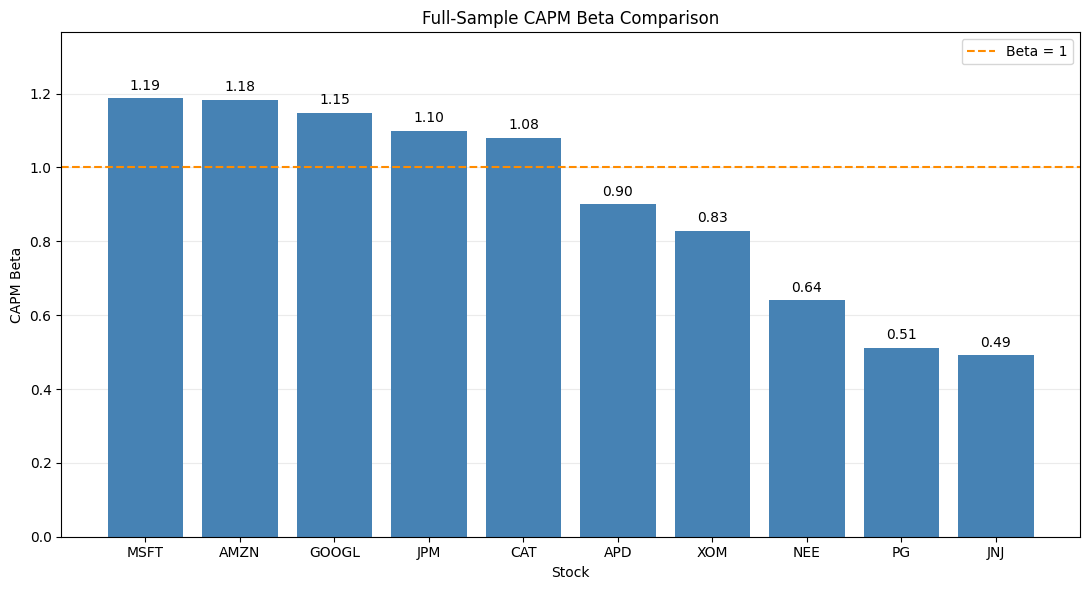

In [45]:
# Compare full-sample CAPM regression betas across stocks
beta_comparison = results_df[["Stock", "Beta"]].sort_values(
    "Beta", ascending=False
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(
    beta_comparison["Stock"],
    beta_comparison["Beta"],
    color="steelblue"
)
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.axhline(1, color="darkorange", linestyle="--", label="Beta = 1")
ax.set_xlabel("Stock")
ax.set_ylabel("CAPM Beta")
ax.set_title("Full-Sample CAPM Beta Comparison")
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.25)
ax.margins(y=0.15)
ax.legend()
fig.tight_layout()

Path("../outputs").mkdir(parents=True, exist_ok=True)
fig.savefig("../outputs/CAPM_beta_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


Scatter plot of stock excess returns vs market excess returns

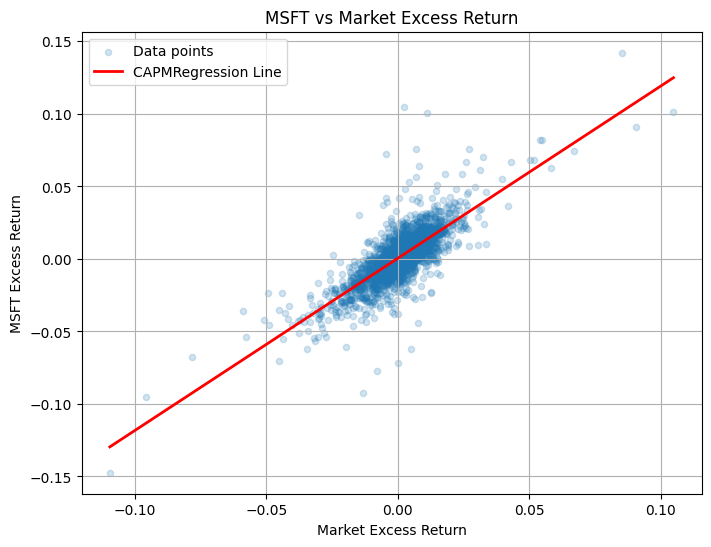

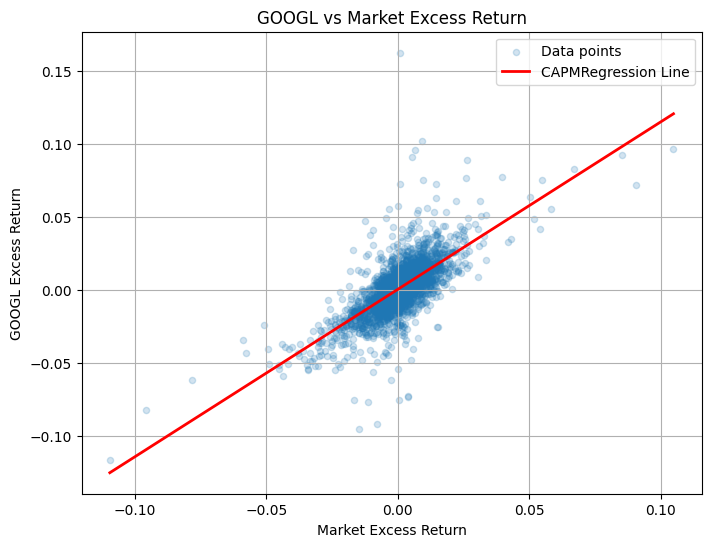

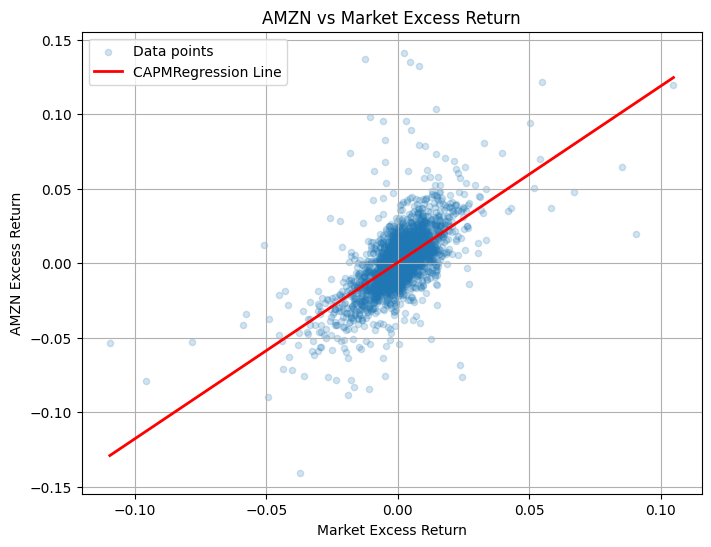

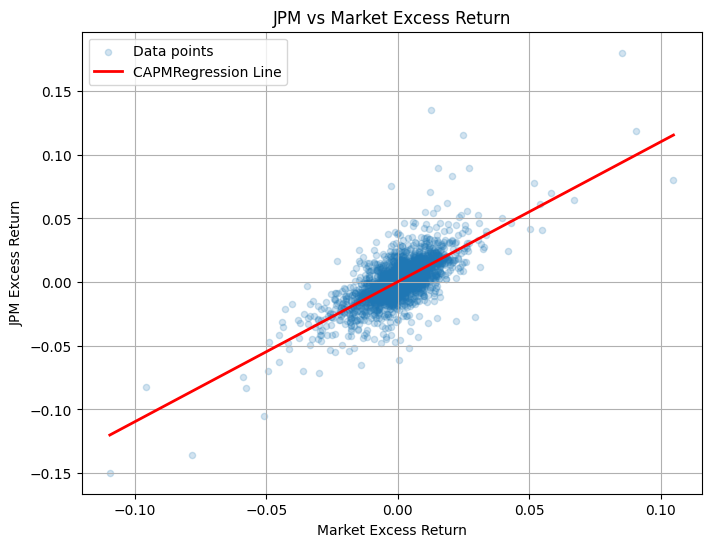

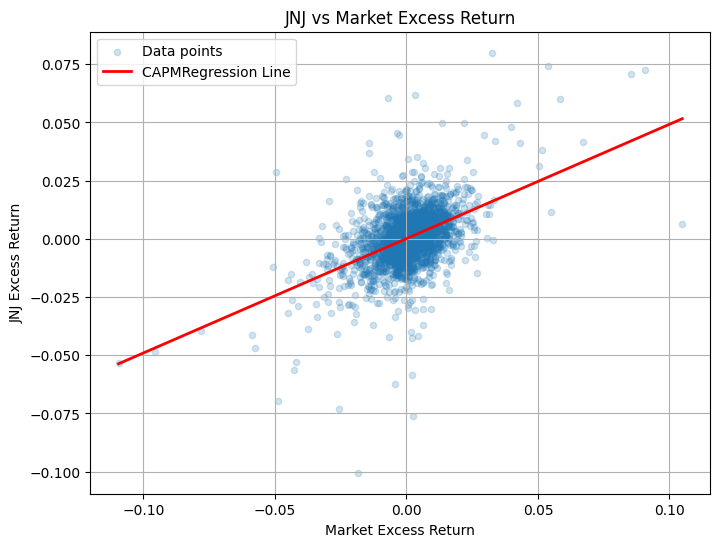

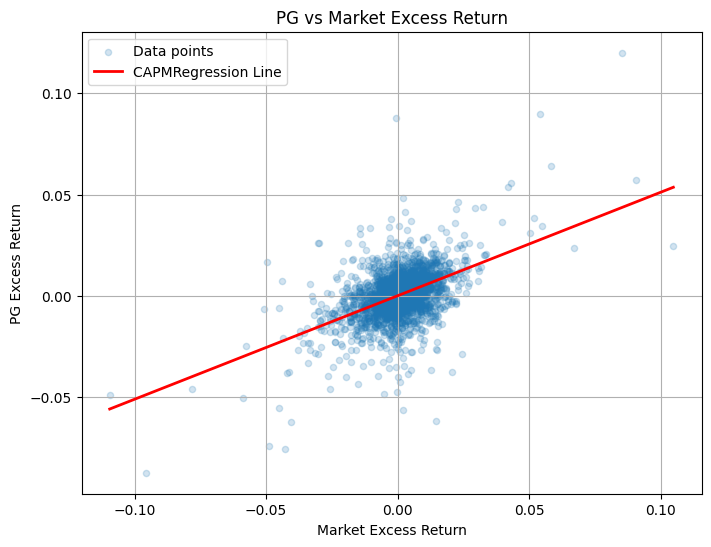

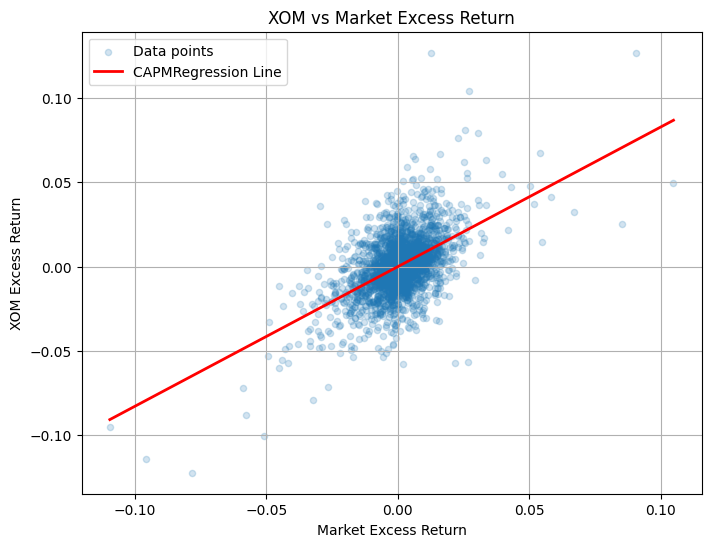

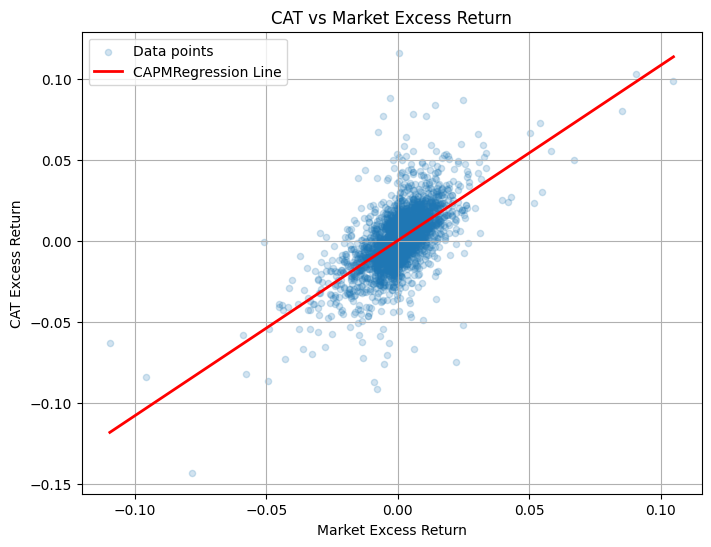

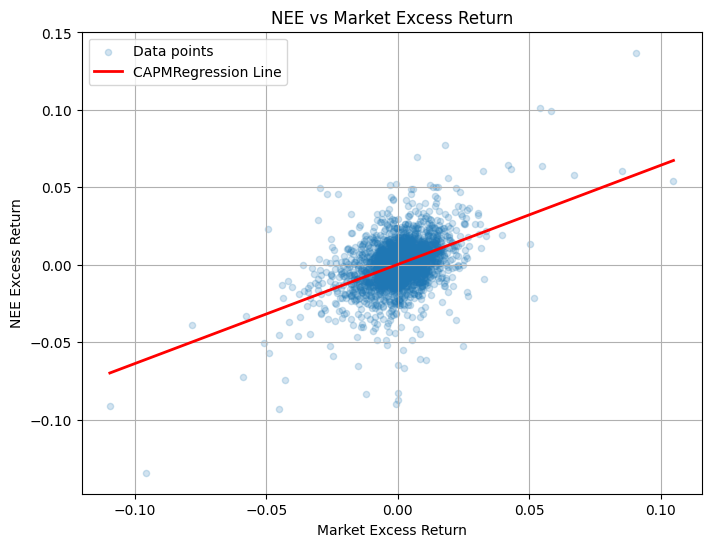

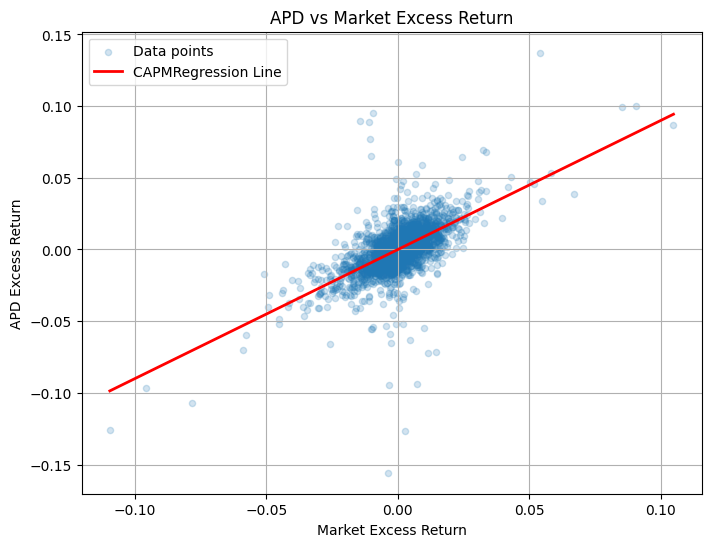

In [46]:
Market_excess_return = df["Market_Excess_Return"]
for stock in stock_excess_cols:
    temp = df[["Market_Excess_Return", stock]].dropna()

    x = temp["Market_Excess_Return"]
    y = temp[stock]

    X_reg = sm.add_constant(x)  # add constant term for intercept
    model = sm. OLS(y, X_reg).fit()

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = (model.params["const"] + model.params["Market_Excess_Return"] * x_line)

    plt.figure(figsize=(8, 6))

     # Plotting dots
    plt.scatter(
        x, 
        y, 
        s = 20, 
        alpha=0.2, 
        label='Data points'
    )

    # Fit regression line
    plt.plot(
        x_line,
        y_line,
        color='red',
        linewidth=2,
        label='CAPMRegression Line'
    )

    plt.title(f'{stock.replace("_Excess_Return", "")} vs Market Excess Return')
    plt.xlabel('Market Excess Return')
    plt.ylabel(f'{stock.replace("_Excess_Return", "")} Excess Return')
    plt.legend()
    plt.grid()

    # plt.savefig(
    #     f"../outputs/{stock}_CAPM.png",
    #     dpi=300,
    #     bbox_inches="tight"
    # )

    plt.show()

Residual plots

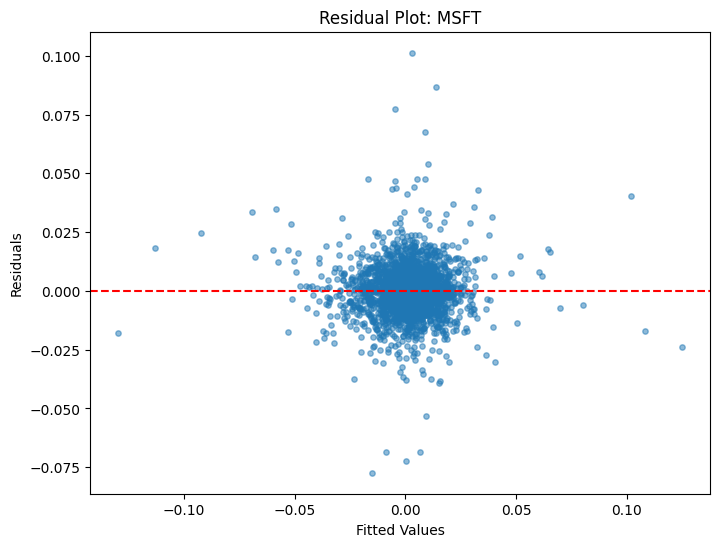

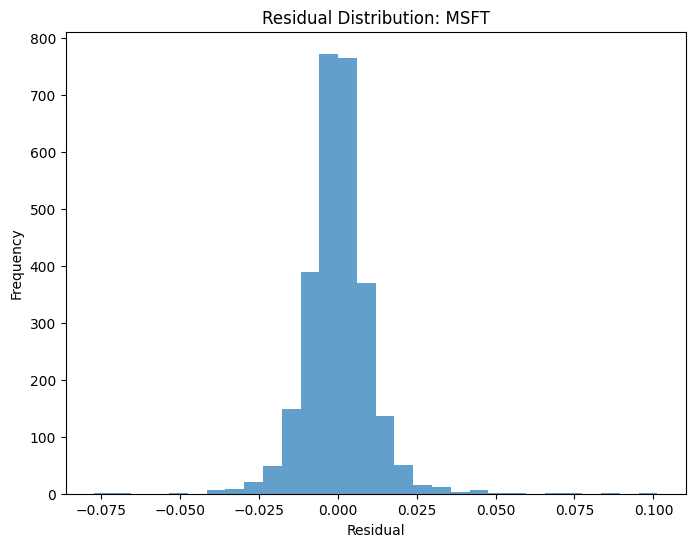

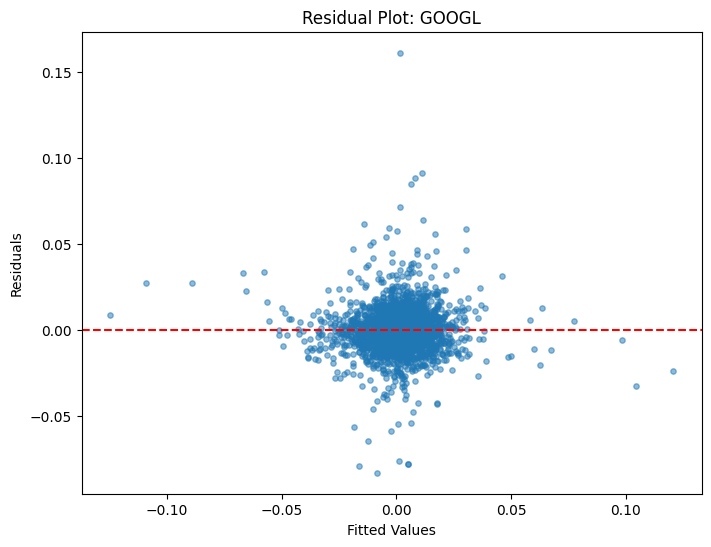

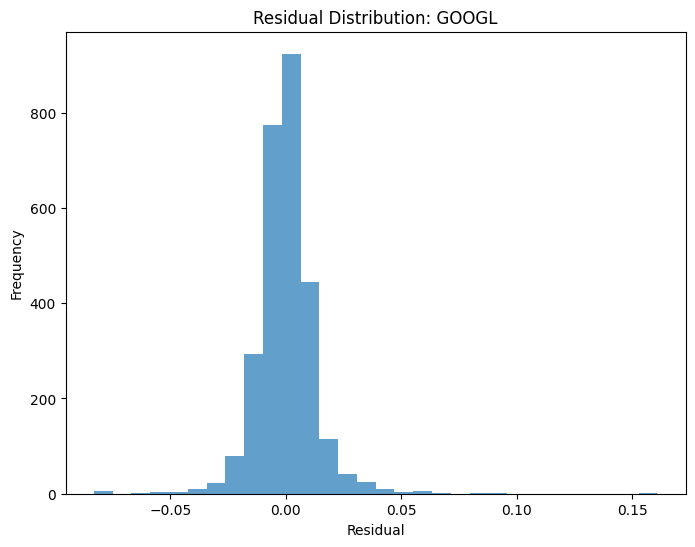

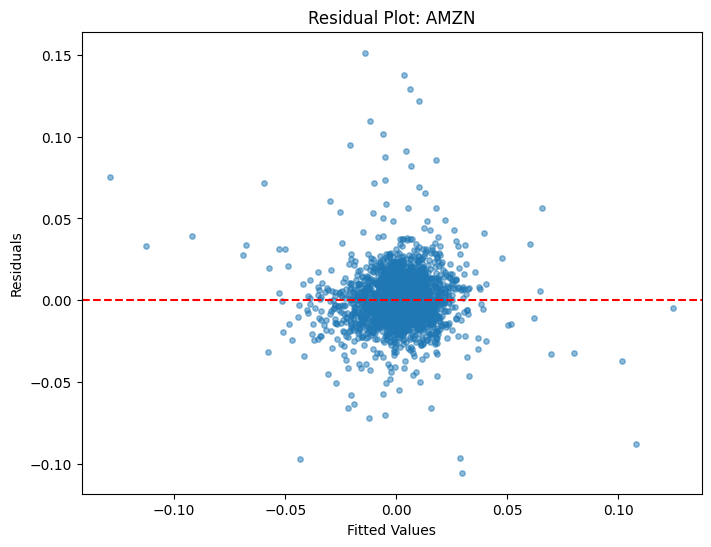

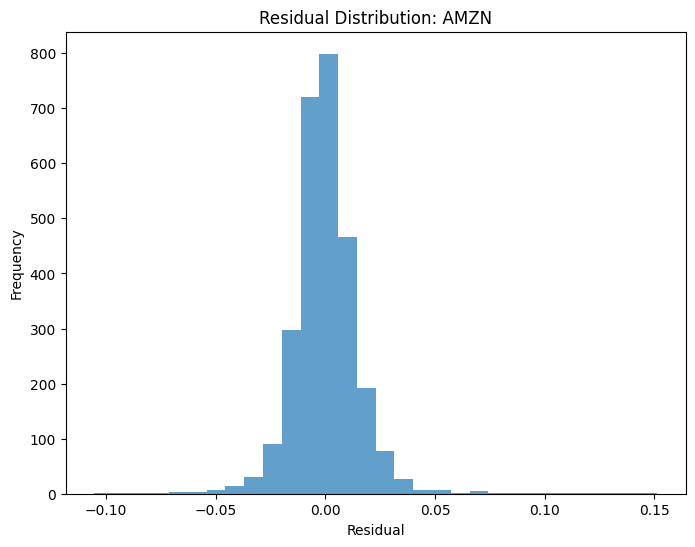

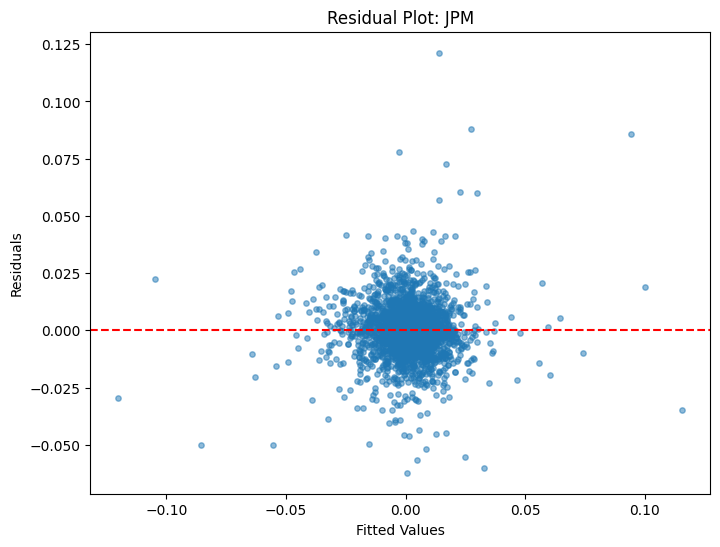

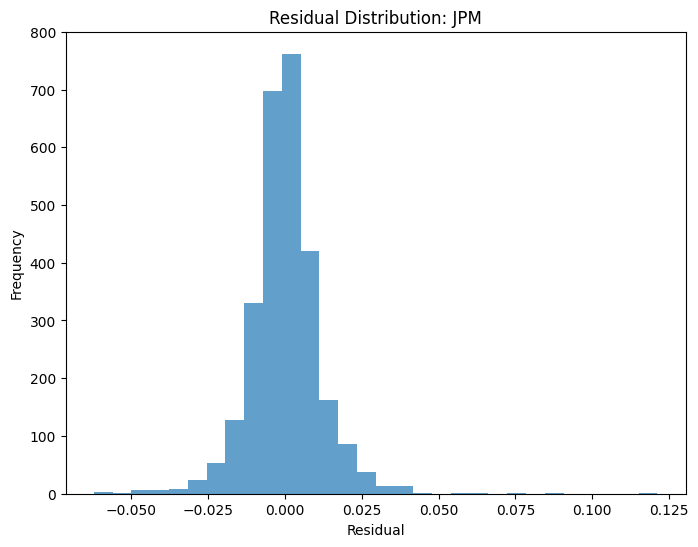

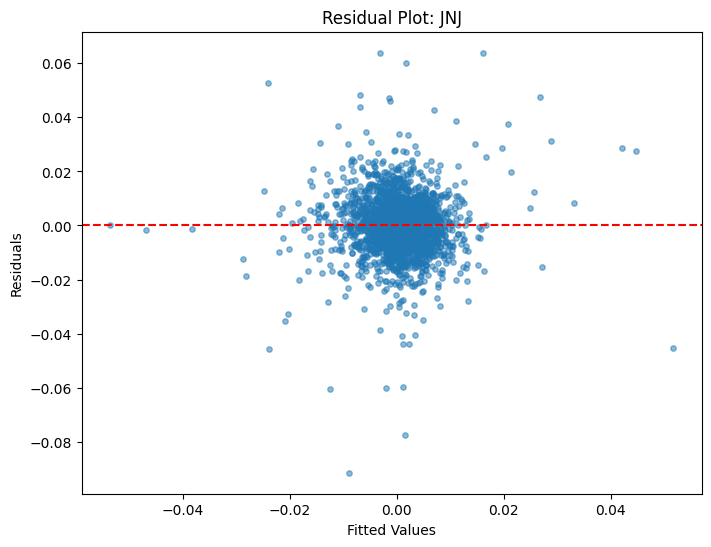

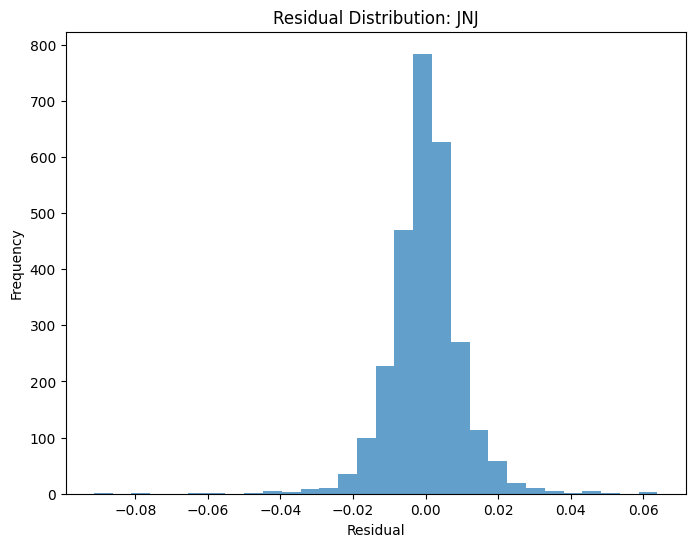

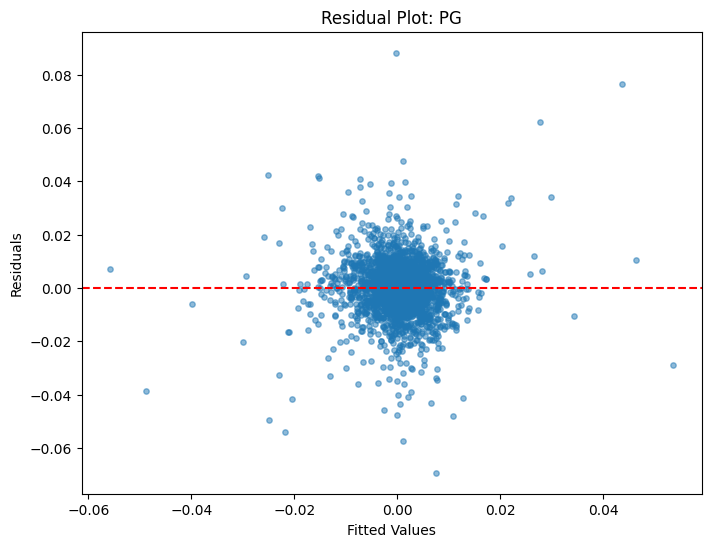

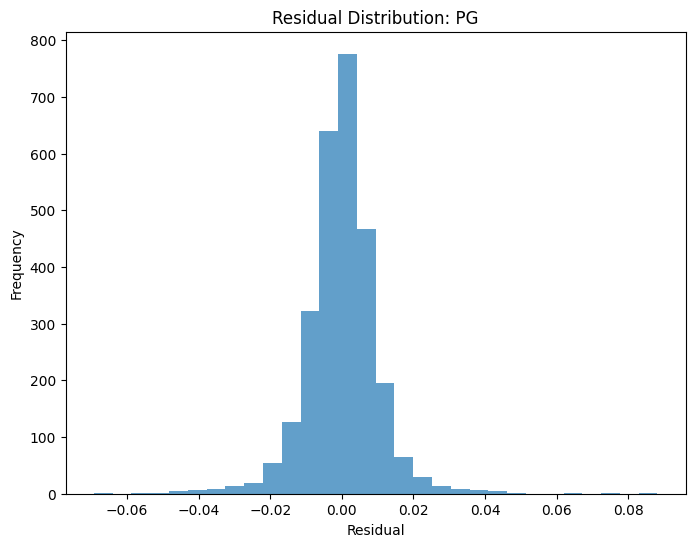

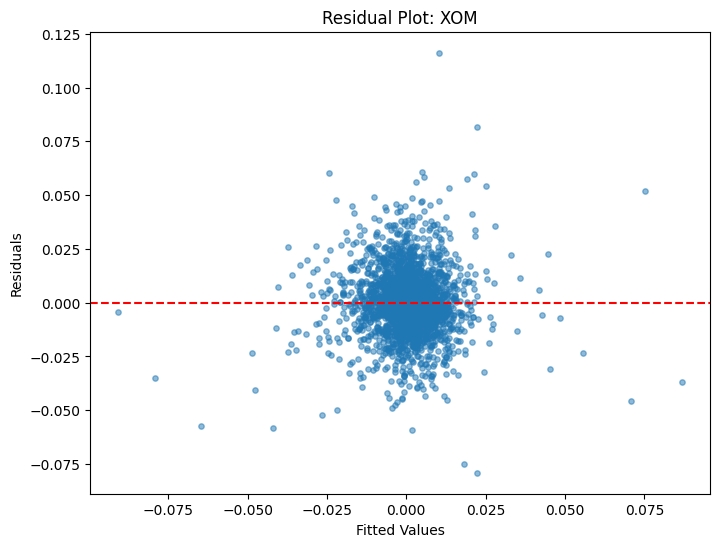

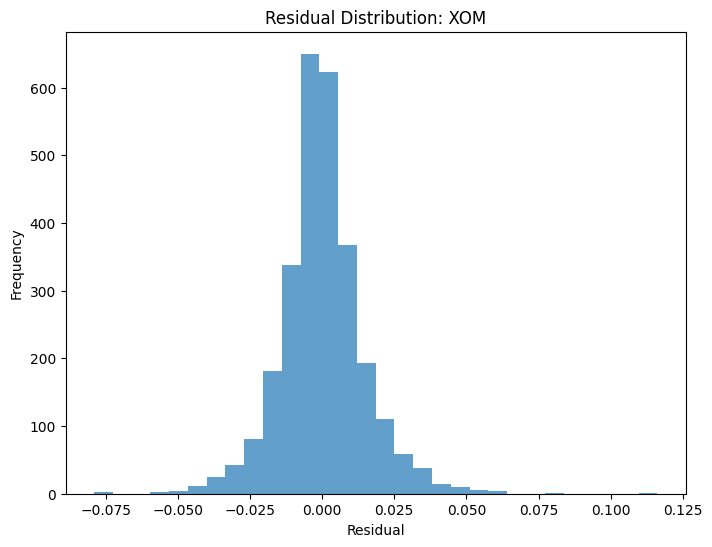

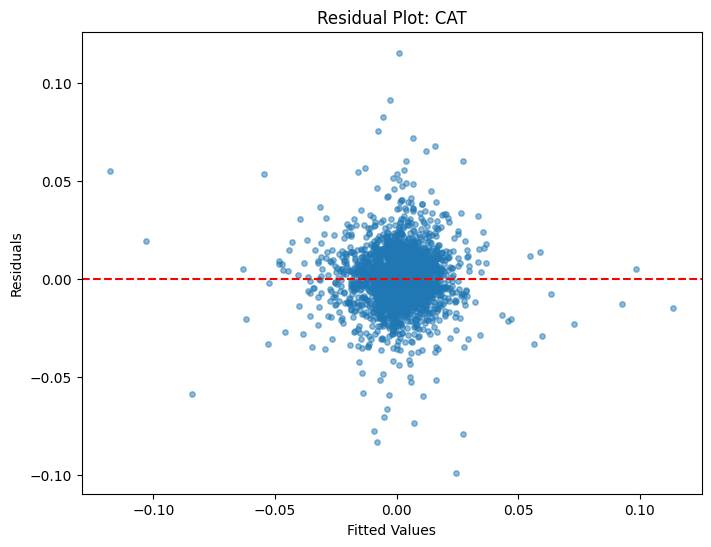

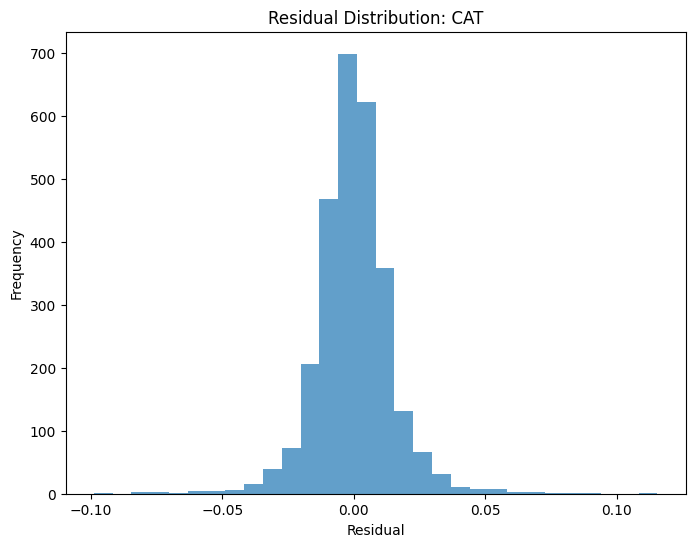

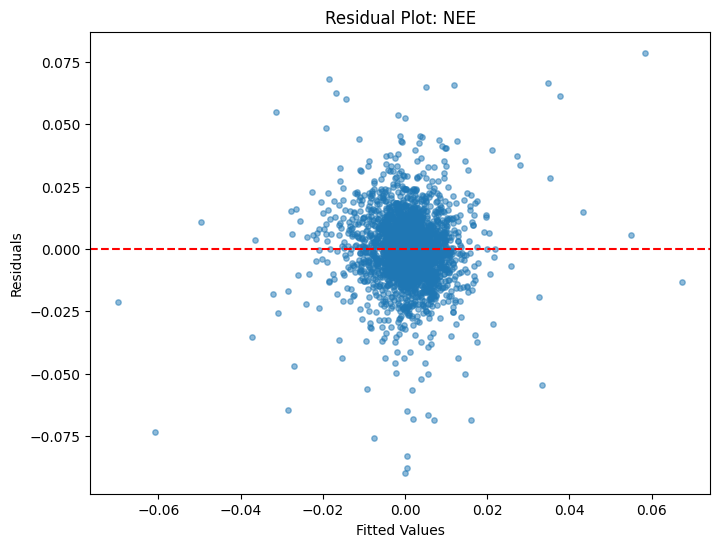

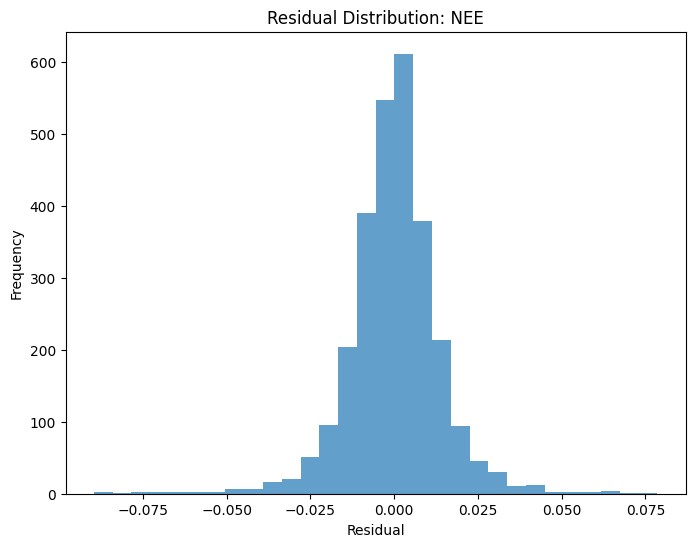

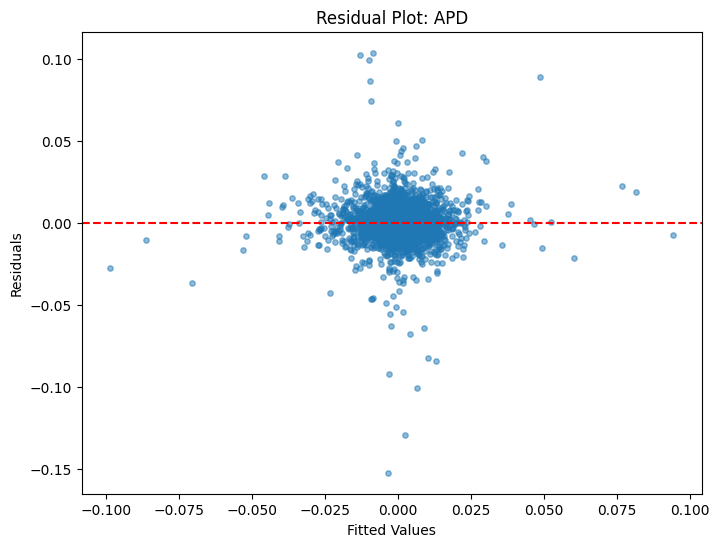

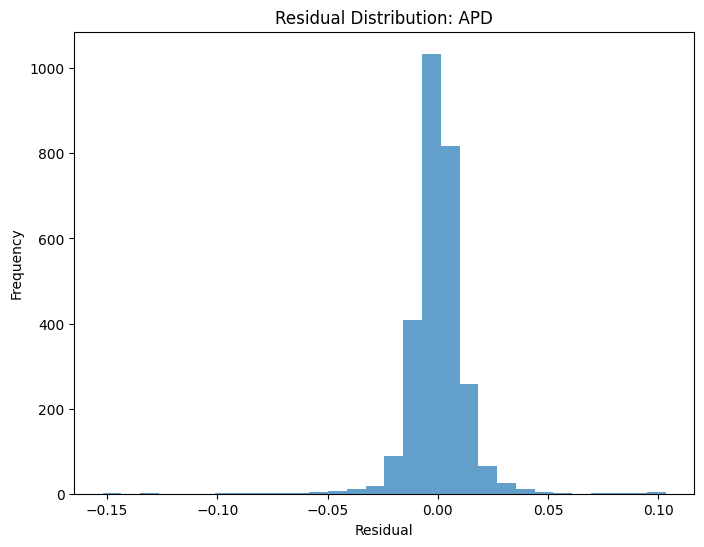

In [47]:
for stock in stock_cols:

    temp = df[["Market_Excess_Return", stock]].dropna()

    X = temp["Market_Excess_Return"]
    y = temp[stock]

    X_reg = sm.add_constant(X)
    model = sm.OLS(y, X_reg).fit()

    residuals = model.resid
    fitted_values = model.fittedvalues

    plt.figure(figsize=(8, 6))

    plt.scatter(
        fitted_values,
        residuals,
        s = 15, 
        alpha = 0.5
    )

    plt.axhline(y=0, linestyle = "--", color = "red")

    plt.title(f'Residual Plot: {stock}')
    plt.xlabel('Fitted Values')
    plt.ylabel('Residuals')

    # plt.savefig(
    #         f"../outputs/{stock}_CAPM.png",
    #         dpi=300,
    #         bbox_inches="tight"
    #     )
    plt.figure(figsize=(8, 6))

    plt.hist(
        residuals,
        bins=30,
        alpha=0.7
    )

    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(f"Residual Distribution: {stock}")

    plt.savefig(
        f"../outputs/{stock}_residual_histogram.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

Rolling beta chart

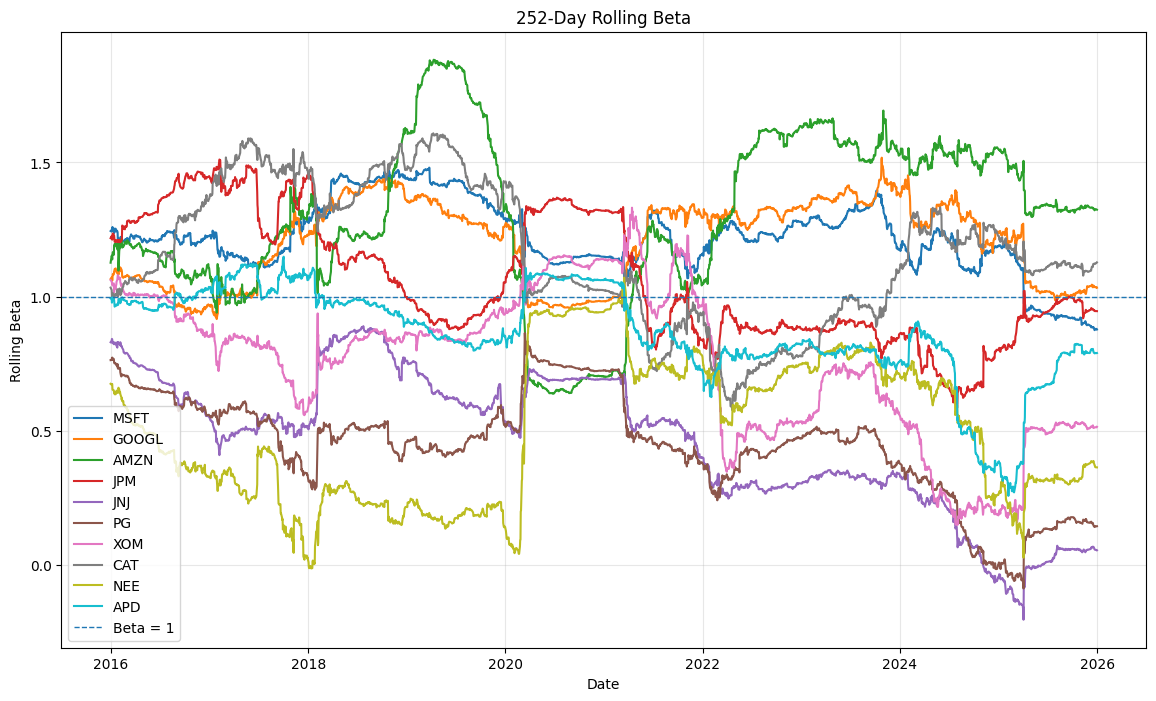

In [48]:
window = 252

stock_cols = [
    col for col in returns.columns
    if col not in ["date", market_col]
]

for stock in stock_cols:
    stock_excess = f"{stock}_Excess_Return"

    df[f"{stock}_Rolling_Beta"] = (
        df[stock_excess]
        .rolling(window)
        .cov(df["Market_Excess_Return"])
        /
        df["Market_Excess_Return"]
        .rolling(window)
        .var()
    )

plt.figure(figsize=(14, 8))

for stock in stock_cols:
    plt.plot(
        df["date"],
        df[f"{stock}_Rolling_Beta"],
        label=stock
    )

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1,
    label="Beta = 1"
)

plt.xlabel("Date")
plt.ylabel("Rolling Beta")
plt.title("252-Day Rolling Beta")
plt.legend()
plt.grid(alpha=0.3)

# plt.savefig(
#         f"../outputs/rolling_beta.png",
#         dpi=300,
#         bbox_inches="tight"
#     )

plt.show()

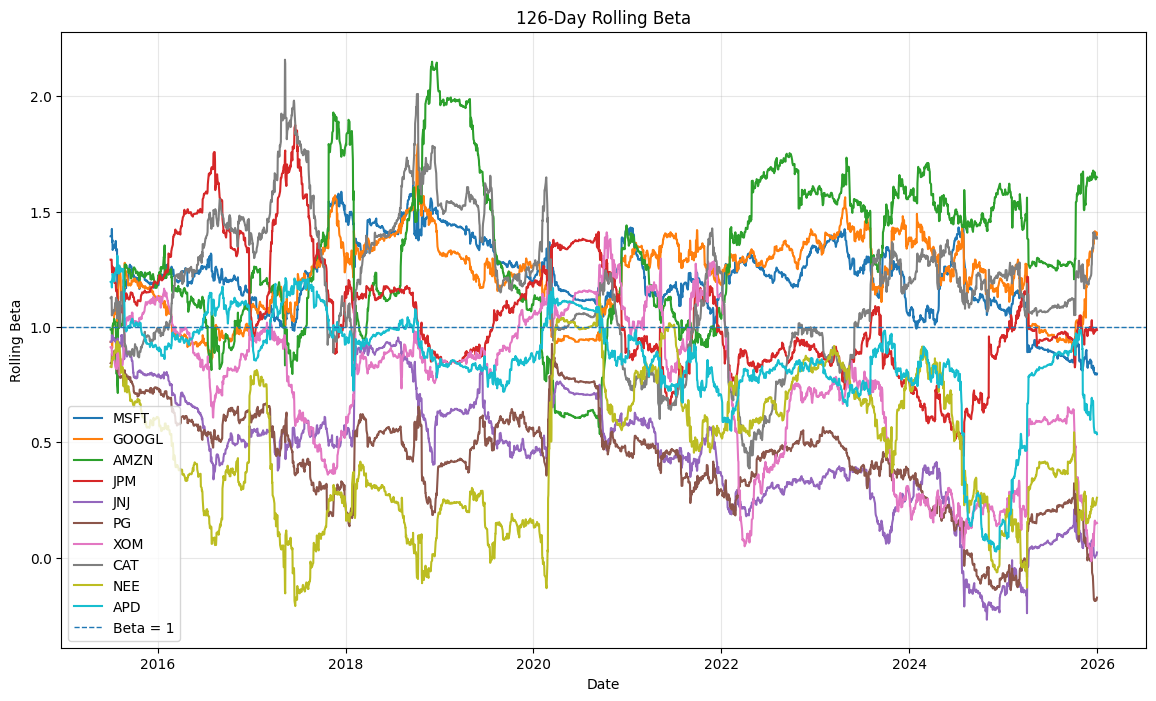

In [49]:
window = 126

stock_cols = [
    col for col in returns.columns
    if col not in ["date", market_col]
]

for stock in stock_cols:
    stock_excess = f"{stock}_Excess_Return"

    df[f"{stock}_Rolling_Beta"] = (
        df[stock_excess]
        .rolling(window)
        .cov(df["Market_Excess_Return"])
        /
        df["Market_Excess_Return"]
        .rolling(window)
        .var()
    )

plt.figure(figsize=(14, 8))

for stock in stock_cols:
    plt.plot(
        df["date"],
        df[f"{stock}_Rolling_Beta"],
        label=stock
    )

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1,
    label="Beta = 1"
)

plt.xlabel("Date")
plt.ylabel("Rolling Beta")
plt.title("126-Day Rolling Beta")
plt.legend()
plt.grid(alpha=0.3)

# plt.savefig(
#         f"../outputs/rolling_beta.png",
#         dpi=300,
#         bbox_inches="tight"
#     )

plt.show()